In [2]:
# Figure 3

import netCDF4 as nc4
import numpy as np
import glob as glob
import matplotlib.pyplot as plt
from scipy import stats



import glob as glob
import os
from collections import OrderedDict
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc4
import matplotlib.pyplot as plt
import matplotlib as mpl
from pylab import *; 
import cartopy
import cartopy.crs as ccrs
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300



def pop_add_cyclic(ds): # pass an xarray object into this
    nj = ds.TLAT.shape[0] # size of POP grid
    ni = ds.TLONG.shape[1]
    xL = int(ni/2 - 1)
    xR = int(xL + ni)
    tlon = ds.TLONG.data
    tlat = ds.TLAT.data
    tlon = np.where(np.greater_equal(tlon, min(tlon[:,0])), tlon-360., tlon) #make monotoncially increasing
    lon  = np.concatenate((tlon, tlon + 360.), 1) # concatenate to make larger array
    lon = lon[:, xL:xR] #restrict to middle rane
    if ni == 320: # this is the x1 POP grid
        print('\n')
    lon = lon - 360.
    lon = np.hstack((lon, lon[:, 0:1] + 360.)) # add in cyclic point
    if ni == 320:
        print('\n')
    #-- periodicity
    lat = np.concatenate((tlat, tlat), 1)
    lat = lat[:, xL:xR]
    lat = np.hstack((lat, lat[:,0:1]))
    TLAT = xr.DataArray(lat, dims=('nlat', 'nlon'))
    TLONG = xr.DataArray(lon, dims=('nlat', 'nlon'))
    dso = xr.Dataset({'TLAT': TLAT, 'TLONG': TLONG})
    # copy vars
    varlist = [v for v in ds.data_vars if v not in ['TLAT', 'TLONG']]
    for v in varlist:
        v_dims = ds[v].dims
        if not ('nlat' in v_dims and 'nlon' in v_dims):
            dso[v] = ds[v]
        else:
            # determine and sort other dimensions
            other_dims = set(v_dims) - {'nlat', 'nlon'}
            other_dims = tuple([d for d in v_dims if d in other_dims])
            lon_dim = ds[v].dims.index('nlon')
            field = ds[v].data
            field = np.concatenate((field, field), lon_dim)
            field = field[..., :, xL:xR]
            field = np.concatenate((field, field[..., :, 0:1]), lon_dim)       
            dso[v] = xr.DataArray(field, dims=other_dims+('nlat', 'nlon'), 
                                  attrs=ds[v].attrs)
    # copy coords
    for v, da in ds.coords.items():
        if not ('nlat' in da.dims and 'nlon' in da.dims):
            dso = dso.assign_coords(**{v: da})     
    return dso


    
    

def get_colors(string,num,add_white = -1):
    #from pylab import *; 
    cmap = cm.get_cmap(string, num)    # PiYG
    colors=[]
    for i in range(cmap.N):
        rgb = cmap(i)[:3] # will return rgba, we take only first 3 so we get rgb
        colors.append(str(matplotlib.colors.rgb2hex(rgb))) 
    if add_white != -1:
        colors.insert(add_white,'#FFFFFF')
    return colors







from datetime import datetime, timedelta

def convert_days_to_date(days_since_origin, origin_date_str="0001-01-01"):
    """
    Converts a number of days since a specified origin date to an actual date.

    Args:
        days_since_origin (int or float): The number of days since the origin.
        origin_date_str (str): The origin date in 'YYYY-MM-DD' format.

    Returns:
        datetime.datetime: The calculated actual date and time.
    """
    # 1. Define the origin date as a datetime object
    origin_date = datetime.strptime(origin_date_str, "%Y-%m-%d")

    # 2. Create a timedelta object from the number of days
    delta = timedelta(days=days_since_origin)

    # 3. Add the timedelta to the origin date to get the resulting date
    actual_date = origin_date + delta

    return actual_date


In [3]:
#Create maps showing difference in productivity between alluv and ctluv simulations during all years of 150 tg simulation


# get files for total phytoplankton NPP first for the cases we care about 
data_directory = '/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/'



these_cases=['fosi_ur_150tg_01_alluv','nw_cntrl_tuv_01','nw_ur_150_tuv_01','fosi_ur_150tg_01_ctluv']#,'fosi_ur_150tg_tuv_01']
VARIABLES=['photoC_diaz','photoC_TOT','photoC_diat','photoC_sp','photoC_cocco']
files={}
for case in these_cases:
    files[case]={}
    for VAR in VARIABLES:
        files[case][VAR]=sorted(glob.glob(data_directory+case+'/'+case+'.pop.h.'+VAR+'.00*.nc'))

    
files[case]

{'photoC_diaz': [],
 'photoC_TOT': ['/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/fosi_ur_150tg_01_ctluv/fosi_ur_150tg_01_ctluv.pop.h.photoC_TOT.000502-002101.nc'],
 'photoC_diat': ['/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/fosi_ur_150tg_01_ctluv/fosi_ur_150tg_01_ctluv.pop.h.photoC_diat.000502-002101.nc'],
 'photoC_sp': ['/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/fosi_ur_150tg_01_ctluv/fosi_ur_150tg_01_ctluv.pop.h.photoC_sp.000502-002101.nc'],
 'photoC_cocco': ['/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/fosi_ur_150tg_01_ctluv/fosi_ur_150tg_01_ctluv.pop.h.photoC_cocco.000502-002101.nc']}

In [4]:
#Create maps showing difference in productivity between alluv and ctluv simulations during all years of 150 tg simulation

example_file=files['fosi_ur_150tg_01_alluv'][VAR][0]

these_cases=['fosi_ur_150tg_01_ctluv','fosi_ur_150tg_01_alluv','nw_ur_150_tuv_01']  # look at alluv and ctluv cases
VARIABLES=['photoC_TOT']
monthly_data={}
for case in these_cases:
    monthly_data[case]={}
    


In [21]:

case='fosi_ur_150tg_01_ctluv'
for YEAR in range(15):
    for var in VARIABLES:
        temp_files=files[case][var]#[YEAR]
        print(YEAR,var)#temp_files)
        cesm_mon_ds=xr.open_mfdataset(temp_files)#,decode_times=False,decode_coords=False, concat_dim='time')
        cesm_mon_ds = cesm_mon_ds.isel(time=slice(5 + YEAR*12, 17 + YEAR*12))
        print(cesm_mon_ds.time[0].values,cesm_mon_ds.time[-1].values)#
        cesm_mon_ds = cesm_mon_ds.mean(dim='time') # select from june to may and avg
        cesm_mon_ds = pop_add_cyclic(cesm_mon_ds)
        variables=[var] 
        coords = {'x':'TLONG','y':'TLAT'}
        keepthese=['z_t','z_t_150m','time_bound','TAREA','REGION_MASK'] + variables
        keep_vars = keepthese +list(coords.values())+['dz','KMT','time']
        cesm_mon_ds = cesm_mon_ds.drop_vars([v for v in cesm_mon_ds.variables if v not in keep_vars])
        key_code = ' YEAR '+str(YEAR)
        monthly_data[case][var+key_code] =  cesm_mon_ds[var].isel(z_t_150m=0)#.mean(dim='time') # this is surface 
        
        

  

0 photoC_TOT
0005-07-01 00:00:00 0006-06-01 00:00:00




1 photoC_TOT
0006-07-01 00:00:00 0007-06-01 00:00:00




2 photoC_TOT
0007-07-01 00:00:00 0008-06-01 00:00:00




3 photoC_TOT
0008-07-01 00:00:00 0009-06-01 00:00:00




4 photoC_TOT
0009-07-01 00:00:00 0010-06-01 00:00:00




5 photoC_TOT
0010-07-01 00:00:00 0011-06-01 00:00:00




6 photoC_TOT
0011-07-01 00:00:00 0012-06-01 00:00:00




7 photoC_TOT
0012-07-01 00:00:00 0013-06-01 00:00:00




8 photoC_TOT
0013-07-01 00:00:00 0014-06-01 00:00:00




9 photoC_TOT
0014-07-01 00:00:00 0015-06-01 00:00:00




10 photoC_TOT
0015-07-01 00:00:00 0016-06-01 00:00:00




11 photoC_TOT
0016-07-01 00:00:00 0017-06-01 00:00:00




12 photoC_TOT
0017-07-01 00:00:00 0018-06-01 00:00:00




13 photoC_TOT
0018-07-01 00:00:00 0019-06-01 00:00:00




14 photoC_TOT
0019-07-01 00:00:00 0020-06-01 00:00:00






dict_keys(['photoC_TOT YEAR 0', 'photoC_TOT YEAR 1', 'photoC_TOT YEAR 2', 'photoC_TOT YEAR 3', 'photoC_TOT YEAR 4', 'photoC_TOT YEAR 5', 'photoC_TOT YEAR 6', 'photoC_TOT YEAR 7', 'photoC_TOT YEAR 8', 'photoC_TOT YEAR 9', 'photoC_TOT YEAR 10', 'photoC_TOT YEAR 11', 'photoC_TOT YEAR 12', 'photoC_TOT YEAR 13', 'photoC_TOT YEAR 14'])

In [22]:

case='fosi_ur_150tg_01_alluv'
for YEAR in range(15):
    for var in VARIABLES:
        temp_files=files[case][var]#[YEAR]
        print(YEAR,var)#temp_files)
        cesm_mon_ds=xr.open_mfdataset(temp_files)#,decode_times=False,decode_coords=False, concat_dim='time')
        cesm_mon_ds = cesm_mon_ds.isel(time=slice(5 + YEAR*12, 17 + YEAR*12))
        print(cesm_mon_ds.time[0].values,cesm_mon_ds.time[-1].values)#
        cesm_mon_ds = cesm_mon_ds.mean(dim='time') # select from june to may and avg
        cesm_mon_ds = pop_add_cyclic(cesm_mon_ds)
        variables=[var] 
        coords = {'x':'TLONG','y':'TLAT'}
        keepthese=['z_t','z_t_150m','time_bound','TAREA','REGION_MASK'] + variables
        keep_vars = keepthese +list(coords.values())+['dz','KMT','time']
        cesm_mon_ds = cesm_mon_ds.drop_vars([v for v in cesm_mon_ds.variables if v not in keep_vars])
        key_code = ' YEAR '+str(YEAR)
        monthly_data[case][var+key_code] =  cesm_mon_ds[var].isel(z_t_150m=0)#.mean(dim='time') # this is surface 
        
        


0 photoC_TOT
0005-07-01 00:00:00 0006-06-01 00:00:00




1 photoC_TOT
0006-07-01 00:00:00 0007-06-01 00:00:00




2 photoC_TOT
0007-07-01 00:00:00 0008-06-01 00:00:00




3 photoC_TOT
0008-07-01 00:00:00 0009-06-01 00:00:00




4 photoC_TOT
0009-07-01 00:00:00 0010-06-01 00:00:00




5 photoC_TOT
0010-07-01 00:00:00 0011-06-01 00:00:00




6 photoC_TOT
0011-07-01 00:00:00 0012-06-01 00:00:00




7 photoC_TOT
0012-07-01 00:00:00 0013-06-01 00:00:00




8 photoC_TOT
0013-07-01 00:00:00 0014-06-01 00:00:00




9 photoC_TOT
0014-07-01 00:00:00 0015-06-01 00:00:00




10 photoC_TOT
0015-07-01 00:00:00 0016-06-01 00:00:00




11 photoC_TOT
0016-07-01 00:00:00 0017-06-01 00:00:00




12 photoC_TOT
0017-07-01 00:00:00 0018-06-01 00:00:00




13 photoC_TOT
0018-07-01 00:00:00 0019-06-01 00:00:00




14 photoC_TOT
0019-07-01 00:00:00 0020-06-01 00:00:00






In [43]:
# get lat/lon data from data we know works

# need to run this because something is wrong with gridding information in processed files ......

extract_biome=nc4.Dataset('/projects/joco6825/fay_biomes_POP.nc','r')
biome_mask = extract_biome.variables['fay_biomes'][:].T

case='nw_ur_150_tuv_01'
for YEAR in range(1):
    for var in VARIABLES:
        temp_files=files[case][var]#[YEAR]
        print(YEAR,var)#temp_files)
        cesm_mon_ds=xr.open_mfdataset(temp_files)#,decode_times=False,decode_coords=False, concat_dim='time')
        cesm_mon_ds = cesm_mon_ds.isel(time=slice(5 + YEAR*12, 17 + YEAR*12))
        print(cesm_mon_ds.time[0].values,cesm_mon_ds.time[-1].values)#
        cesm_mon_ds = cesm_mon_ds.mean(dim='time') # select from june to may and avg
        cesm_mon_ds['biomes'] = (('nlat','nlon'), biome_mask) # add biome_mask
        cesm_mon_ds = pop_add_cyclic(cesm_mon_ds)
        variables=[var] 
        coords = {'x':'TLONG','y':'TLAT'}
        keepthese=['z_t','z_t_150m','time_bound','TAREA','REGION_MASK'] + variables
        keep_vars = keepthese +list(coords.values())+['dz','KMT','time']
        #cesm_mon_ds = cesm_mon_ds.drop_vars([v for v in cesm_mon_ds.variables if v not in keep_vars])
        key_code = ' YEAR '+str(YEAR)
        monthly_data[case][var+key_code] =  cesm_mon_ds[var].isel(z_t_150m=0)#.mean(dim='time') # this is surface 
        
        

0 photoC_TOT
0005-07-01 00:00:00 0006-06-01 00:00:00






In [44]:
cesm_mon_ds

<xarray.Dataset> Size: 11MB
Dimensions:     (nlat: 384, nlon: 321, z_t_150m: 15, z_t: 60)
Coordinates:
  * z_t_150m    (z_t_150m) float32 60B 500.0 1.5e+03 ... 1.35e+04 1.45e+04
  * z_t         (z_t) float32 240B 500.0 1.5e+03 2.5e+03 ... 5.125e+05 5.375e+05
Dimensions without coordinates: nlat, nlon
Data variables:
    TLAT        (nlat, nlon) float64 986kB dask.array<chunksize=(384, 161), meta=np.ndarray>
    TLONG       (nlat, nlon) float64 986kB dask.array<chunksize=(384, 161), meta=np.ndarray>
    photoC_TOT  (z_t_150m, nlat, nlon) float32 7MB dask.array<chunksize=(15, 384, 161), meta=np.ndarray>
    TAREA       (nlat, nlon) float64 986kB dask.array<chunksize=(384, 161), meta=np.ndarray>
    dz          (z_t) float32 240B dask.array<chunksize=(60,), meta=np.ndarray>
    biomes      (nlat, nlon) float64 986kB nan nan nan nan ... nan nan nan nan

In [45]:
temp = files['fosi_ur_150tg_01_alluv'][var][0]
extract=nc4.Dataset(temp,'r')
TAREA_m2 = extract.variables['TAREA'][:]*(100**-2)
surface_thickness = extract.variables['dz'][0,0] * (100**-1) 




def get_colors(string,num,add_white = -1):
    #from pylab import *; 
    cmap = cm.get_cmap(string, num)    # PiYG
    colors=[]
    for i in range(cmap.N):
        rgb = cmap(i)[:3] # will return rgba, we take only first 3 so we get rgb
        colors.append(str(matplotlib.colors.rgb2hex(rgb))) 
    if add_white != -1:
        colors.insert(add_white,'#FFFFFF')
    return colors



mpl.rcParams['figure.dpi'] = 150
# make a da plot
# now create plot of NPP during impact winter (varying colorbars)
def get_colors(string,num,add_white = -1):
    #from pylab import *; 
    cmap = cm.get_cmap(string, num)    # PiYG
    colors=[]
    for i in range(cmap.N):
        rgb = cmap(i)[:3] # will return rgba, we take only first 3 so we get rgb
        colors.append(str(matplotlib.colors.rgb2hex(rgb))) 
    if add_white != -1:
        colors.insert(add_white,'#FFFFFF')
    return colors

FONTSIZE={}
FONTSIZE['SUPTITLE']=16
FONTSIZE['TITLE']=12
FONTSIZE['YLABEL']=12
FONTSIZE['XLABEL']=12
FONTSIZE['XTICKS']=12
FONTSIZE['CBAR_TICKS'] = 12
unit_factor = 12*1e-2*1e-3 *86400
lats = cesm_mon_ds.variables['TLAT']; lons=cesm_mon_ds.variables['TLONG']
lats_c = lats; lons_c = lons;
axes={}
pc={}
#axes['photoC_TOT_zint']=fig.add_subplot(gs[0,0],facecolor='darkgrey',projection=ccrs.Robinson(central_longitude=-60)) # this plot will be pic/poc during recovery 
boundaries={}
colors={}
cmap={}
norm={}
PFT_number={}
PFT_title={}
PFT_title['photoC_TOT'] = 'All phytoplankton'
PFT_title['photoC_diat']='Diatoms'
PFT_title['photoC_cocco']='Coccolithophores'
PFT_title['photoC_sp']='Small phytoplankton'



for PFT in ['photoC_TOT']:#,'photoC_diat_zint']:
    boundaries[PFT]=np.array([-3,-2,-1.5,-1,-0.5,0.5,1,1.5,2,3])*1e-15
    #cmap_seismic = plt.cm.get_cmap('seismic',len(boundaries[PFT]))
    #colors[PFT] = list(cmap_seismic(np.arange(len(boundaries[PFT]))))
    #cmap[PFT] = mpl.colors.ListedColormap(colors[PFT], "")
    ###
    nboundaries = len(boundaries[PFT])
    colors_diff = get_colors('BrBG',nboundaries,add_white= -5)
    cmap[PFT] = mpl.colors.ListedColormap(colors_diff, "")
    colors[PFT] = colors_diff
    
    ###
    #norm[PFT] = mpl.colors.BoundaryNorm(boundaries[PFT],ncolors=nboundaries-1,clip=False)
    norm[PFT] = mpl.colors.TwoSlopeNorm(vmin=boundaries[PFT][0],vcenter=0,vmax=boundaries[PFT][-1]) 


/tmp/ipykernel_2035495/1108397892.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(string, num)    # PiYG


In [46]:




################################################
#
#
# Convert to biome map
#
#
#
#
#
###############################################


# MOST USER SPECIFICATIONS ARE HERE  these_cases=['fosi_ur_150tg_01_ctluv_start001205','fosi_ur_150tg_01_alluv'] 
PFT='photoC_TOT' 
PANELS = ['panel1','panel2','panel3']
panel_title={}; plot_data={}


panel_title['panel1'] = 'Year 6'; key_code='YEAR 6';
PERTURBED_DATA = monthly_data['fosi_ur_150tg_01_alluv'][PFT+' '+key_code] # use this as a baseline
CONTROL_DATA = monthly_data['fosi_ur_150tg_01_ctluv'][PFT+' '+key_code]
plot_data['panel1'] = PERTURBED_DATA - CONTROL_DATA # monthly_data[case][PFT+' '+key_code]
#plot_data['panel1'] = plot_data['panel1'] * CONTROL_DATA**-1 * 100.0


panel_title['panel2'] = 'Year 7'; key_code='YEAR 7'; #plot_data['panel2'] = monthly_data[case][PFT+' '+key_code]-CONTROL_DATA
PERTURBED_DATA = monthly_data['fosi_ur_150tg_01_alluv'][PFT+' '+key_code]
CONTROL_DATA = monthly_data['fosi_ur_150tg_01_ctluv'][PFT+' '+key_code] # use this as a baseline
plot_data['panel2'] = PERTURBED_DATA - CONTROL_DATA# monthly_data[case][PFT+' '+key_code]
#plot_data['panel2'] = plot_data['panel2'] * CONTROL_DATA**-1 * 100.0


panel_title['panel3'] = 'Year 8'; key_code='YEAR 8'; #plot_data['panel3'] = monthly_data[case][PFT+' '+key_code]-CONTROL_DATA
PERTURBED_DATA = monthly_data['fosi_ur_150tg_01_alluv'][PFT+' '+key_code]
CONTROL_DATA = monthly_data['fosi_ur_150tg_01_ctluv'][PFT+' '+key_code] # use this as a baseline
plot_data['panel3'] = PERTURBED_DATA - CONTROL_DATA # monthly_data[case][PFT+' '+key_code]
#plot_data['panel3'] = plot_data['panel3'] * CONTROL_DATA**-1 * 100.0

scale_factor=(1000**-1)*(12.011)*(86400)*(365)#*(1e-15) # grams of Carbon
POSTPROCESSING = True
if POSTPROCESSING:
    for key in plot_data.keys():
        plot_data[key] = plot_data[key] * surface_thickness * scale_factor # Pg C yr-1 per meter squared 
        plot_data[key] = np.nan_to_num(plot_data[key])
        
        biome_separated_npp = np.array(plot_data[key])*0.0 # replicate this and then we will replace at the end of loop
        
        for current_biome in range(1,18): # cycle through 17 biomes 
            #temporary_plot_data = np.array(plot_data[key]) # get temporary array
            temporary_biome_mask = np.array(cesm_mon_ds['biomes']) # get biome mask for current_biome 
            #temporary_plot_data[temporary_biome_mask != current_biome] = 0.0 # zero out 
            
            temporary_tarea = np.array(cesm_mon_ds.TAREA)*(100**-2)
            temporary_tarea[temporary_biome_mask != current_biome] = 0.0 # zero out tarea when not in current_biome
            
            biome_average_npp = np.average( plot_data[key], weights=temporary_tarea)
            biome_separated_npp[temporary_biome_mask == current_biome] = biome_average_npp # apply biome average npp to bounds of biome 
        plot_data[key] = biome_separated_npp
            
    








/tmp/ipykernel_2035495/1108397892.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(string, num)    # PiYG


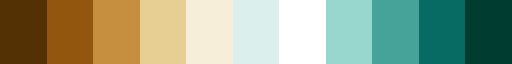

In [34]:
colors_diff = get_colors('BrBG',nboundaries,add_white=6)
cmap[PFT] = mpl.colors.ListedColormap(colors_diff, "")
cmap[PFT]

/tmp/ipykernel_2035495/1108397892.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(string, num)    # PiYG
/tmp/ipykernel_2035495/3388696576.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


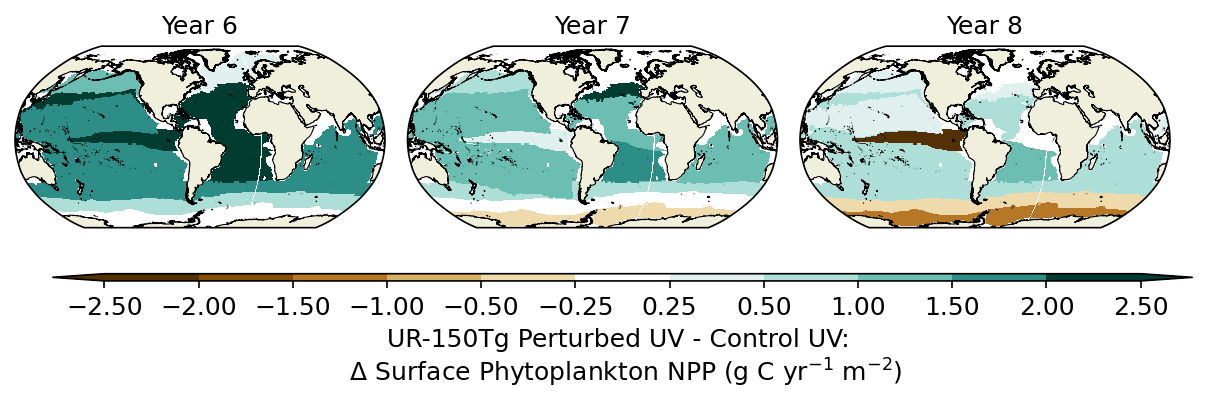

In [47]:



############
#
#
# Figure generation starts here 
#
#
############
    
for PFT in ['photoC_TOT']:#,'photoC_diat_zint']:
    boundaries[PFT]=np.array([-2.5,-2,-1.5,-1,-0.5,-0.25,0.25,0.5,1,1.5,2,2.5])
    #cmap_seismic = plt.cm.get_cmap('seismic',len(boundaries[PFT]))
    #colors[PFT] = list(cmap_seismic(np.arange(len(boundaries[PFT]))))
    #cmap[PFT] = mpl.colors.ListedColormap(colors[PFT], "")
    ###
    nboundaries = len(boundaries[PFT])
    colors_diff = get_colors('BrBG',nboundaries,add_white=6)
    cmap[PFT] = mpl.colors.ListedColormap(colors_diff, "")
    colors[PFT] = colors_diff
    
    ###
    norm[PFT] = mpl.colors.BoundaryNorm(boundaries[PFT],ncolors=nboundaries+1,clip=False)
    #norm[PFT] = MidpointNormalize(vmin=boundaries[PFT][0], vmax=boundaries[PFT][-1], midpoint=0)
    #norm[PFT] = mpl.colors.TwoSlopeNorm(vmin=boundaries[PFT][0],vcenter=0,vmax=boundaries[PFT][-1]) 
    
    
    
    
    

land_object=cartopy.feature.NaturalEarthFeature('physical', 'land', '10m',
                                edgecolor='k',linewidth=0.5,
                                facecolor=cartopy.feature.COLORS['land'])


fig = plt.figure(figsize=(8,2.4),facecolor='white',num=1,clear=True)
gs = fig.add_gridspec(1,3) # photoC_TOT_zint
#plt.suptitle('Total column phytoplankton NPP',fontsize=FONTSIZE['SUPTITLE'])
subplot_number=0
for panel in PANELS:
    axes[panel]=fig.add_subplot(gs[0,0 + subplot_number],facecolor='white',projection=ccrs.Robinson(central_longitude=-60))
    axes[panel].set_title(panel_title[panel],fontsize=FONTSIZE['TITLE'])
    pc[panel]=axes[panel].pcolormesh(lons.values,lats.values,plot_data[panel], cmap=cmap[PFT],norm=norm[PFT],
    transform=ccrs.PlateCarree())     
    axes[panel].add_feature(land_object)
    subplot_number = subplot_number+1



position = fig.add_axes([0.05,0.1,0.95,0.02]) # left,bottom,width,height
cbar1=fig.colorbar(pc[panel],cax=position,extend='both',orientation='horizontal')
cbar1.ax.tick_params(labelsize=FONTSIZE['CBAR_TICKS'])
cbar1.set_ticks(boundaries[PFT])
#cbar1.set_label('CTLUV - ALLUV $\Delta$ Phytoplankton NPP (% difference)',fontsize=FONTSIZE['XLABEL'])
cbar1.set_label('UR-150Tg Perturbed UV - Control UV: \n $\Delta$ Surface Phytoplankton NPP (g C yr$^{-1}$ m$^{-2}$)',fontsize=FONTSIZE['XLABEL'])
     

plt.tight_layout()





In [48]:
# MOST USER SPECIFICATIONS ARE HERE  these_cases=['fosi_ur_150tg_01_ctluv_start001205','fosi_ur_150tg_01_alluv'] 
PFT='photoC_TOT' 
PANELS = ['panel1','panel2','panel3']
panel_title={}; plot_data={}


panel_title['panel1'] = 'Year 9'; key_code='YEAR 9';
PERTURBED_DATA = monthly_data['fosi_ur_150tg_01_alluv'][PFT+' '+key_code] # use this as a baseline
CONTROL_DATA = monthly_data['fosi_ur_150tg_01_ctluv'][PFT+' '+key_code]
plot_data['panel1'] = PERTURBED_DATA - CONTROL_DATA # monthly_data[case][PFT+' '+key_code]
#plot_data['panel1'] = plot_data['panel1'] * CONTROL_DATA**-1 * 100.0


panel_title['panel2'] = 'Year 10'; key_code='YEAR 10'; #plot_data['panel2'] = monthly_data[case][PFT+' '+key_code]-CONTROL_DATA
PERTURBED_DATA = monthly_data['fosi_ur_150tg_01_alluv'][PFT+' '+key_code]
CONTROL_DATA = monthly_data['fosi_ur_150tg_01_ctluv'][PFT+' '+key_code] # use this as a baseline
plot_data['panel2'] = PERTURBED_DATA - CONTROL_DATA# monthly_data[case][PFT+' '+key_code]
#plot_data['panel2'] = plot_data['panel2'] * CONTROL_DATA**-1 * 100.0


panel_title['panel3'] = 'Year 11'; key_code='YEAR 11'; #plot_data['panel3'] = monthly_data[case][PFT+' '+key_code]-CONTROL_DATA
PERTURBED_DATA = monthly_data['fosi_ur_150tg_01_alluv'][PFT+' '+key_code]
CONTROL_DATA = monthly_data['fosi_ur_150tg_01_ctluv'][PFT+' '+key_code] # use this as a baseline
plot_data['panel3'] = PERTURBED_DATA - CONTROL_DATA # monthly_data[case][PFT+' '+key_code]
#plot_data['panel3'] = plot_data['panel3'] * CONTROL_DATA**-1 * 100.0

scale_factor=(1000**-1)*(12.011)*(86400)*(365)#*(1e-15)
POSTPROCESSING = True
if POSTPROCESSING:
    for key in plot_data.keys():
        plot_data[key] = plot_data[key] * surface_thickness * scale_factor # Pg C yr-1 per meter squared 
        plot_data[key] = np.nan_to_num(plot_data[key])
        
        biome_separated_npp = np.array(plot_data[key])*0.0 # replicate this and then we will replace at the end of loop
        
        for current_biome in range(1,18): # cycle through 17 biomes 
            #temporary_plot_data = np.array(plot_data[key]) # get temporary array
            temporary_biome_mask = np.array(cesm_mon_ds['biomes']) # get biome mask for current_biome 
            #temporary_plot_data[temporary_biome_mask != current_biome] = 0.0 # zero out 
            
            temporary_tarea = np.array(cesm_mon_ds.TAREA)*(100**-2)
            temporary_tarea[temporary_biome_mask != current_biome] = 0.0 # zero out tarea when not in current_biome
            
            biome_average_npp = np.average( plot_data[key], weights=temporary_tarea)
            biome_separated_npp[temporary_biome_mask == current_biome] = biome_average_npp # apply biome average npp to bounds of biome 
        plot_data[key] = biome_separated_npp
            
    



/tmp/ipykernel_2035495/1108397892.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(string, num)    # PiYG
/tmp/ipykernel_2035495/354250382.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


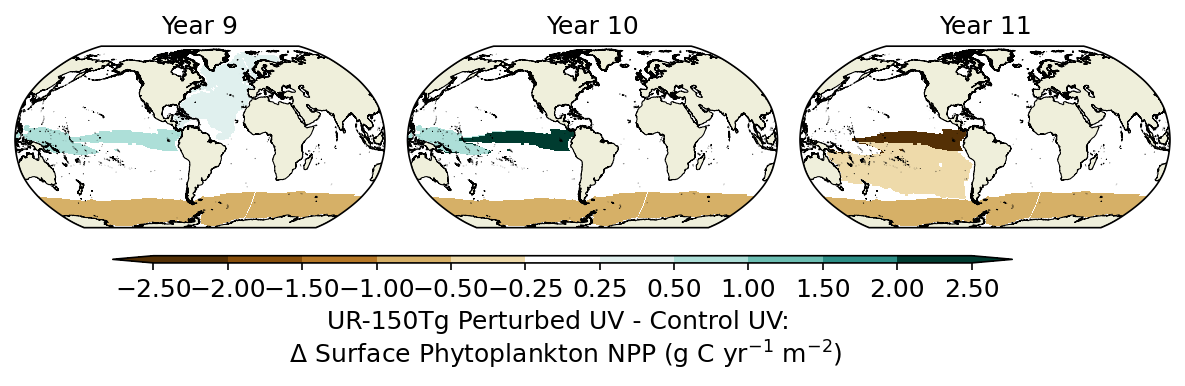

In [49]:

############
#
#
# Figure generation starts here 
#
#
############
for PFT in ['photoC_TOT']:#,'photoC_diat_zint']:
    boundaries[PFT]=np.array([-2.5,-2,-1.5,-1,-0.5,-0.25,0.25,0.5,1,1.5,2,2.5])
    #cmap_seismic = plt.cm.get_cmap('seismic',len(boundaries[PFT]))
    #colors[PFT] = list(cmap_seismic(np.arange(len(boundaries[PFT]))))
    #cmap[PFT] = mpl.colors.ListedColormap(colors[PFT], "")
    ###
    nboundaries = len(boundaries[PFT])
    colors_diff = get_colors('BrBG',nboundaries,add_white=6)
    cmap[PFT] = mpl.colors.ListedColormap(colors_diff, "")
    colors[PFT] = colors_diff
    
    ###
    norm[PFT] = mpl.colors.BoundaryNorm(boundaries[PFT],ncolors=nboundaries+1,clip=False)
    #norm[PFT] = MidpointNormalize(vmin=boundaries[PFT][0], vmax=boundaries[PFT][-1], midpoint=0)
    #norm[PFT] = mpl.colors.TwoSlopeNorm(vmin=boundaries[PFT][0],vcenter=0,vmax=boundaries[PFT][-1]) 
    
    
    

land_object=cartopy.feature.NaturalEarthFeature('physical', 'land', '10m',
                                edgecolor='k',linewidth=0.5,
                                facecolor=cartopy.feature.COLORS['land'])


fig = plt.figure(figsize=(8,2.4),facecolor='white',num=1,clear=True)
gs = fig.add_gridspec(1,3) # photoC_TOT_zint
#plt.suptitle('Total column phytoplankton NPP',fontsize=FONTSIZE['SUPTITLE'])
subplot_number=0
for panel in PANELS:
    axes[panel]=fig.add_subplot(gs[0,0 + subplot_number],facecolor='white',projection=ccrs.Robinson(central_longitude=-60))
    axes[panel].set_title(panel_title[panel],fontsize=FONTSIZE['TITLE'])
    pc[panel]=axes[panel].pcolormesh(lons.values,lats.values,plot_data[panel], cmap=cmap[PFT],
    norm=norm[PFT],transform=ccrs.PlateCarree())     
    axes[panel].add_feature(land_object)
    subplot_number = subplot_number+1



position = fig.add_axes([0.10,0.15,0.75,0.02]) # left,bottom,width,height
cbar1=fig.colorbar(pc[panel],cax=position,extend='both',orientation='horizontal')
cbar1.ax.tick_params(labelsize=FONTSIZE['CBAR_TICKS'])
cbar1.set_ticks(boundaries[PFT])
#cbar1.set_label('CTLUV - ALLUV $\Delta$ Phytoplankton NPP (% difference)',fontsize=FONTSIZE['XLABEL'])
cbar1.set_label('UR-150Tg Perturbed UV - Control UV: \n $\Delta$ Surface Phytoplankton NPP (g C yr$^{-1}$ m$^{-2}$)',fontsize=FONTSIZE['XLABEL'])
     

plt.tight_layout()




In [50]:
# MOST USER SPECIFICATIONS ARE HERE  these_cases=['fosi_ur_150tg_01_ctluv_start001205','fosi_ur_150tg_01_alluv'] 
PFT='photoC_TOT' 
PANELS = ['panel1','panel2','panel3']
panel_title={}; plot_data={}


panel_title['panel1'] = 'Year 12'; key_code='YEAR 12';
PERTURBED_DATA = monthly_data['fosi_ur_150tg_01_alluv'][PFT+' '+key_code] # use this as a baseline
CONTROL_DATA = monthly_data['fosi_ur_150tg_01_ctluv'][PFT+' '+key_code]
plot_data['panel1'] = PERTURBED_DATA - CONTROL_DATA # monthly_data[case][PFT+' '+key_code]
#plot_data['panel1'] = plot_data['panel1'] * CONTROL_DATA**-1 * 100.0


panel_title['panel2'] = 'Year 13'; key_code='YEAR 13'; #plot_data['panel2'] = monthly_data[case][PFT+' '+key_code]-CONTROL_DATA
PERTURBED_DATA = monthly_data['fosi_ur_150tg_01_alluv'][PFT+' '+key_code]
CONTROL_DATA = monthly_data['fosi_ur_150tg_01_ctluv'][PFT+' '+key_code] # use this as a baseline
plot_data['panel2'] = PERTURBED_DATA - CONTROL_DATA# monthly_data[case][PFT+' '+key_code]
#plot_data['panel2'] = plot_data['panel2'] * CONTROL_DATA**-1 * 100.0


panel_title['panel3'] = 'Year 14'; key_code='YEAR 14'; #plot_data['panel3'] = monthly_data[case][PFT+' '+key_code]-CONTROL_DATA
PERTURBED_DATA = monthly_data['fosi_ur_150tg_01_alluv'][PFT+' '+key_code]
CONTROL_DATA = monthly_data['fosi_ur_150tg_01_ctluv'][PFT+' '+key_code] # use this as a baseline
plot_data['panel3'] = PERTURBED_DATA - CONTROL_DATA # monthly_data[case][PFT+' '+key_code]
#plot_data['panel3'] = plot_data['panel3'] * CONTROL_DATA**-1 * 100.0

scale_factor=(1000**-1)*(12.011)*(86400)*(365)#*(1e-15)
POSTPROCESSING = True
if POSTPROCESSING:
    for key in plot_data.keys():
        plot_data[key] = plot_data[key] * surface_thickness * scale_factor # Pg C yr-1 per meter squared 
        plot_data[key] = np.nan_to_num(plot_data[key])
        
        biome_separated_npp = np.array(plot_data[key])*0.0 # replicate this and then we will replace at the end of loop
        
        for current_biome in range(1,18): # cycle through 17 biomes 
            #temporary_plot_data = np.array(plot_data[key]) # get temporary array
            temporary_biome_mask = np.array(cesm_mon_ds['biomes']) # get biome mask for current_biome 
            #temporary_plot_data[temporary_biome_mask != current_biome] = 0.0 # zero out 
            
            temporary_tarea = np.array(cesm_mon_ds.TAREA)*(100**-2)
            temporary_tarea[temporary_biome_mask != current_biome] = 0.0 # zero out tarea when not in current_biome
            
            biome_average_npp = np.average( plot_data[key], weights=temporary_tarea)
            biome_separated_npp[temporary_biome_mask == current_biome] = biome_average_npp # apply biome average npp to bounds of biome 
        plot_data[key] = biome_separated_npp
            
    


/tmp/ipykernel_2035495/1108397892.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(string, num)    # PiYG
/tmp/ipykernel_2035495/1812355830.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


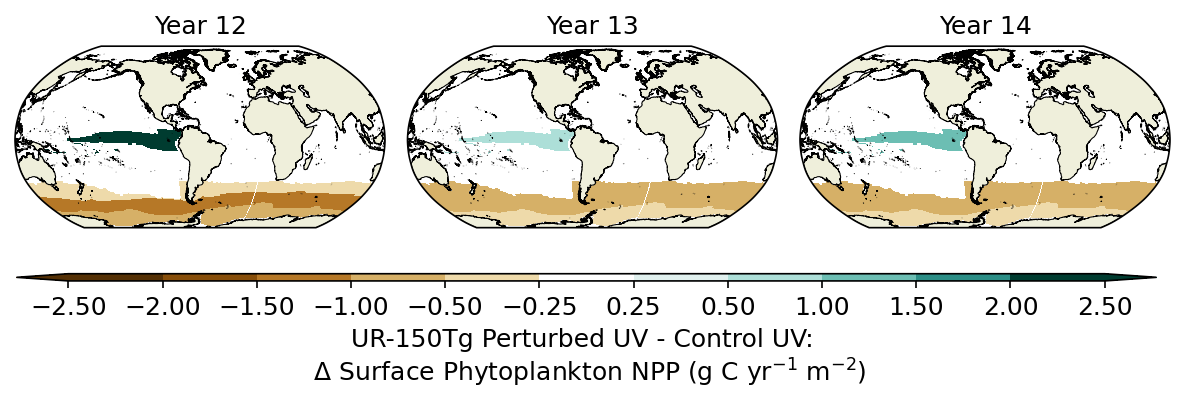

In [51]:

############
#
#
# Figure generation starts here 
#
#
############
for PFT in ['photoC_TOT']:#,'photoC_diat_zint']:
    boundaries[PFT]=np.array([-2.5,-2,-1.5,-1,-0.5,-0.25,0.25,0.5,1,1.5,2,2.5])
    #cmap_seismic = plt.cm.get_cmap('seismic',len(boundaries[PFT]))
    #colors[PFT] = list(cmap_seismic(np.arange(len(boundaries[PFT]))))
    #cmap[PFT] = mpl.colors.ListedColormap(colors[PFT], "")
    ###
    nboundaries = len(boundaries[PFT])
    colors_diff = get_colors('BrBG',nboundaries,add_white=6)
    cmap[PFT] = mpl.colors.ListedColormap(colors_diff, "")
    colors[PFT] = colors_diff
    
    ###
    norm[PFT] = mpl.colors.BoundaryNorm(boundaries[PFT],ncolors=nboundaries+1,clip=False)
    #norm[PFT] = MidpointNormalize(vmin=boundaries[PFT][0], vmax=boundaries[PFT][-1], midpoint=0)
    #norm[PFT] = mpl.colors.TwoSlopeNorm(vmin=boundaries[PFT][0],vcenter=0,vmax=boundaries[PFT][-1]) 
    
    
    

land_object=cartopy.feature.NaturalEarthFeature('physical', 'land', '10m',
                                edgecolor='k',linewidth=0.5,
                                facecolor=cartopy.feature.COLORS['land'])


fig = plt.figure(figsize=(8,2.4),facecolor='white',num=1,clear=True)
gs = fig.add_gridspec(1,3) # photoC_TOT_zint
#plt.suptitle('Total column phytoplankton NPP',fontsize=FONTSIZE['SUPTITLE'])
subplot_number=0
for panel in PANELS:
    axes[panel]=fig.add_subplot(gs[0,0 + subplot_number],facecolor='white',projection=ccrs.Robinson(central_longitude=-60))
    axes[panel].set_title(panel_title[panel],fontsize=FONTSIZE['TITLE'])
    pc[panel]=axes[panel].pcolormesh(lons.values,lats.values,plot_data[panel], cmap=cmap[PFT],
    norm=norm[PFT],transform=ccrs.PlateCarree())     
    axes[panel].add_feature(land_object)
    subplot_number = subplot_number+1



position = fig.add_axes([0.02,0.1,0.95,0.02]) # left,bottom,width,height # left,bottom,width,height
cbar1=fig.colorbar(pc[panel],cax=position,extend='both',orientation='horizontal')
cbar1.ax.tick_params(labelsize=FONTSIZE['CBAR_TICKS'])
cbar1.set_ticks(boundaries[PFT])
#cbar1.set_label('CTLUV - ALLUV $\Delta$ Phytoplankton NPP (% difference)',fontsize=FONTSIZE['XLABEL'])
cbar1.set_label('UR-150Tg Perturbed UV - Control UV: \n $\Delta$ Surface Phytoplankton NPP (g C yr$^{-1}$ m$^{-2}$)',fontsize=FONTSIZE['XLABEL'])
     

plt.tight_layout()


